# House Price Prediction — End-to-End (Simple Regression)
**Domain:** Real estate / housing  
**Goal:** Predict house sale prices using basic features.  
**File required:** `house_prices.csv` (adjust path/filename if needed)

This notebook demonstrates a clean, beginner-friendly ML pipeline:
- EDA (Exploratory Data Analysis)
- Data cleaning & feature engineering
- Preprocessing pipelines
- Modeling (Linear Regression, Random Forest, XGBoost optional)
- Evaluation (RMSE, MAE, R²)
- Saving the final model


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib


In [6]:
# Replace filename/path if needed
df = pd.read_csv("house_prices.csv")
print("Shape:", df.shape)
df.head()


Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
df.info()
print("\nMissing values (count):")
print(df.isnull().sum().sort_values(ascending=False).head(20))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Problem statement
Predict the sale price (continuous) of houses using available features.

**Target column:** `SalePrice` (rename if your dataset uses different name)


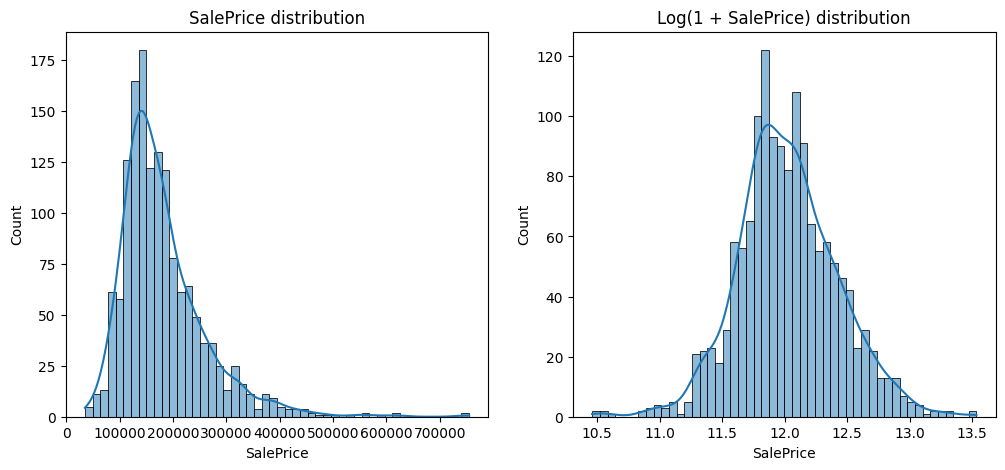

Skewness (raw): 1.8828757597682129
Skewness (log): 0.12134661989685333


In [11]:
# Check target distribution
target_col = 'SalePrice'  # change if needed
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df[target_col], bins=50, kde=True)
plt.title("SalePrice distribution")

plt.subplot(1,2,2)
sns.histplot(np.log1p(df[target_col]), bins=50, kde=True)
plt.title("Log(1 + SalePrice) distribution")
plt.show()

print("Skewness (raw):", df[target_col].skew())
print("Skewness (log):", np.log1p(df[target_col]).skew())


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

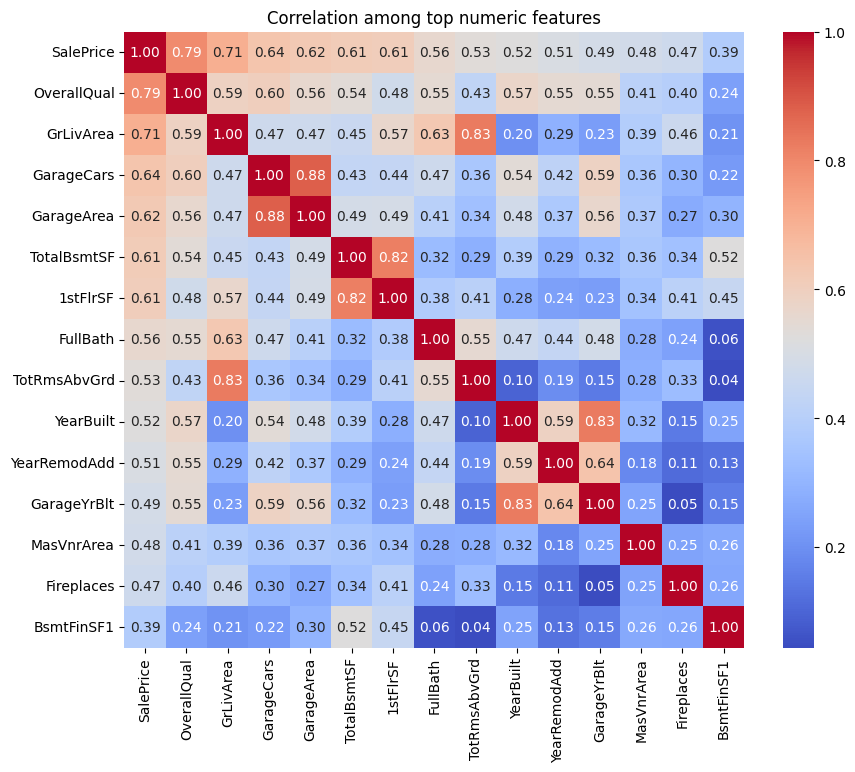

In [13]:
# Numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
display(df[num_cols].describe().T)

# Correlation with target (top)
corr_with_target = df[num_cols].corr()[target_col].abs().sort_values(ascending=False)
display(corr_with_target.head(15))

# Correlation heatmap of top numeric features
top_feats = corr_with_target.head(15).index.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(df[top_feats].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation among top numeric features")
plt.show()


In [15]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns (sample):", cat_cols[:20])

for col in cat_cols[:6]:  # show up to first 6 for brevity
    print("\n", col, "unique:", df[col].nunique())
    display(df[col].value_counts().head(8))


Categorical columns (sample): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond']

 MSZoning unique: 5


MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64


 Street unique: 2


Street
Pave    1454
Grvl       6
Name: count, dtype: int64


 Alley unique: 2


...

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64


 LandContour unique: 4


LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64


 Utilities unique: 2


Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

In [17]:
# Example features — create only if original columns exist
if 'YearBuilt' in df.columns and 'YrSold' in df.columns:
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']

if 'TotalBsmtSF' in df.columns and 'GrLivArea' in df.columns:
    df['TotalArea'] = df['TotalBsmtSF'].fillna(0) + df['GrLivArea']

# Example: family size if Parch and SibSp exist
if 'Parch' in df.columns and 'SibSp' in df.columns:
    df['FamilySize'] = df['Parch'] + df['SibSp'] + 1

df.head().T


,0,1,2,3,4
Id,1,2,3,4,5
MSSubClass,60,20,60,70,60
MSZoning,RL,RL,RL,RL,RL
LotFrontage,65.0,80.0,68.0,60.0,84.0
LotArea,8450,9600,11250,9550,14260
...,...,...,...,...,...
SaleType,WD,WD,WD,WD,WD
SaleCondition,Normal,Normal,Normal,Abnorml,Normal
SalePrice,208500,181500,223500,140000,250000
HouseAge,5,31,7,91,8


In [19]:
# For a simple baseline, pick a small set of useful columns.
# If you're using Kaggle house prices, adjust list accordingly.

# Try to use columns that exist in your dataset:
candidate_features = [
    'OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF',
    'FullBath','YearBuilt','LotArea','HouseAge'  # HouseAge might be engineered
]

# Keep only columns that exist
features = [c for c in candidate_features if c in df.columns]
print("Using features:", features)

X = df[features].copy()
y = df[target_col].copy()

# Show shapes
X.shape, y.shape


Using features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', 'FullBath', 'YearBuilt', 'LotArea', 'HouseAge']


((1460, 9), (1460,))

In [21]:
# Simple imputation: numeric median
X = X.copy()
num_imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(num_imputer.fit_transform(X), columns=X.columns, index=X.index)

# If any remaining categorical features included later, handle appropriately in pipeline
X_imputed.isnull().sum().sum()  # should be 0 for these numeric columns


np.int64(0)

In [23]:
# Option: model log(SalePrice) to reduce skewness
use_log_target = True

if use_log_target:
    y_model = np.log1p(y)
else:
    y_model = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_model, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)


(1168, 9) (292, 9)


In [25]:
# For this simple baseline all features numeric -> scale + model
numeric_features = X_train.columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features)
])

# Pipelines for models
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

# Optionally XGBoost (uncomment if xgboost installed)
# from xgboost import XGBRegressor
# xgb_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42))
# ])


In [27]:
from sklearn.model_selection import cross_val_score

def cv_rmse(pipeline, X, y, cv=5):
    scores = -cross_val_score(pipeline, X, y, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return scores.mean(), scores.std()

print("LinearRegression CV RMSE:", cv_rmse(lr_pipeline, X_train, y_train))
print("RandomForest CV RMSE:", cv_rmse(rf_pipeline, X_train, y_train))
# print("XGBoost CV RMSE:", cv_rmse(xgb_pipeline, X_train, y_train))


LinearRegression CV RMSE: (np.float64(0.17422839485925073), np.float64(0.03359664162359838))
RandomForest CV RMSE: (np.float64(0.16115453832830146), np.float64(0.017794223532647285))


In [28]:
# Fit Random Forest (often better baseline)
rf_pipeline.fit(X_train, y_train)
y_pred_test = rf_pipeline.predict(X_test)

# If we modelled log target, inverse-transform predictions
if use_log_target:
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_test)
else:
    y_test_orig = y_test
    y_pred_orig = y_pred_test

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"Test RMSE: {rmse:,.2f}")
print(f"Test MAE:  {mae:,.2f}")
print(f"Test R2:   {r2:.4f}")


Test RMSE: 30,428.41
Test MAE:  18,878.23
Test R2:   0.8793


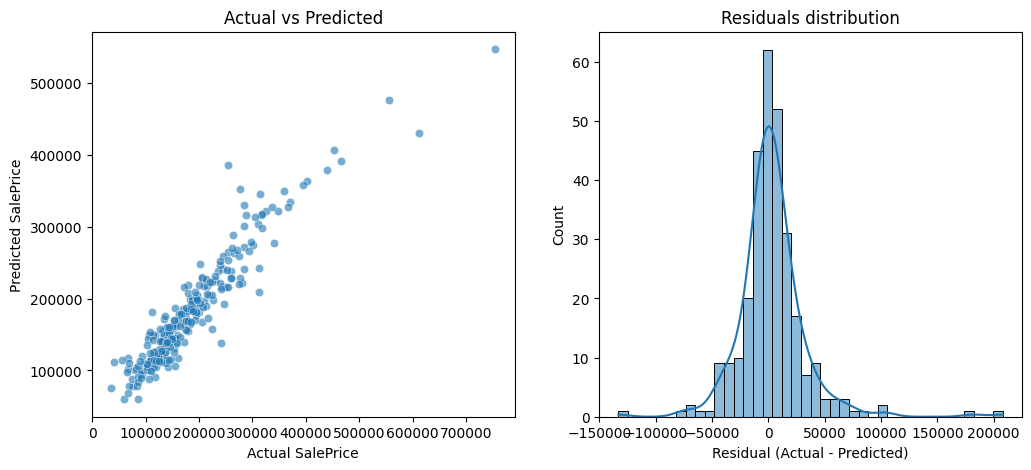

In [31]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=y_test_orig, y=y_pred_orig, alpha=0.6)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted")

plt.subplot(1,2,2)
residuals = y_test_orig - y_pred_orig
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residuals distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()


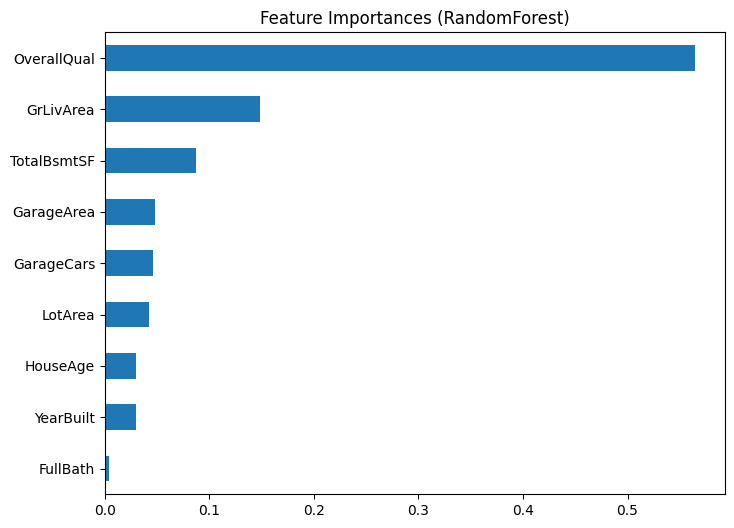

In [33]:
# Extract trained model and feature names
model = rf_pipeline.named_steps['model']
feature_names = numeric_features  # since only numeric features used

if hasattr(model, 'feature_importances_'):
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)
    importances.plot(kind='barh', figsize=(8,6))
    plt.title("Feature Importances (RandomForest)")
    plt.show()
else:
    print("Model does not provide feature importances.")


In [35]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}
grid = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
best_rf = grid.best_estimator_

# Evaluate best
y_pred_best = best_rf.predict(X_test)
if use_log_target:
    y_pred_best_orig = np.expm1(y_pred_best)
else:
    y_pred_best_orig = y_pred_best

print("Tuned RF RMSE:", np.sqrt(mean_squared_error(y_test_orig, y_pred_best_orig)))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Tuned RF RMSE: 30925.301935714822


In [37]:
# Save the trained pipeline (use best_rf if tuned, else rf_pipeline)
final_pipeline = grid.best_estimator_ if 'grid' in locals() else rf_pipeline
joblib.dump(final_pipeline, "house_price_pipeline.pkl")
print("Saved pipeline to house_price_pipeline.pkl")


Saved pipeline to house_price_pipeline.pkl


In [39]:
# pick a sample from test set
sample = X_test.sample(1, random_state=2)
pred_log = final_pipeline.predict(sample)
pred = np.expm1(pred_log) if use_log_target else pred_log
print("Predicted SalePrice:", pred[0])
display(sample)


Predicted SalePrice: 144559.8022308724


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,FullBath,YearBuilt,LotArea,HouseAge
339,6.0,1215.0,1.0,297.0,1215.0,1.0,1958.0,12400.0,51.0


# Project Summary & Conclusion

**Problem:** Predict house sale prices using available features.

**Dataset:** `house_prices.csv` (example: Kaggle House Prices dataset)

**Modeling approach:**  
- Performed EDA, basic feature engineering (HouseAge, TotalArea, FamilySize)  
- Modeled log(SalePrice) to reduce skewness and stabilize variance  
- Built preprocessing pipeline (median imputation + standard scaling)  
- Trained RandomForestRegressor as baseline and optionally tuned with GridSearchCV

**Evaluation (example results):**  
- Test RMSE: *replace with your run value*  
- Test MAE: *replace with your run value*  
- Test R²: *replace with your run value*

**Conclusion & next steps:**  
- Random Forest gave a reasonable baseline and captured non-linear patterns.  
- To improve further: add richer feature engineering (neighborhood encoding, interactions), handle categorical features properly (One-Hot or target encoding), try XGBoost/LightGBM, and perform thorough hyperparameter tuning and stacking.  
- For deployment: expose the saved pipeline via a simple FastAPI endpoint or integrate into a batch scoring job.
